# Modeling evaluation

## Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)

## Load datasets

In [2]:
# Define processed dataset paths
train_baseline_path = "../data/processed/train_baseline.csv"
test_baseline_path = "../data/processed/test_baseline.csv"

train_engineered_path = "../data/processed/train_engineered.csv"
test_engineered_path = "../data/processed/test_engineered.csv"

In [3]:
# Load baseline datasets
df_train_baseline = pd.read_csv(
    train_baseline_path,
    low_memory=False
)

In [4]:
df_test_baseline = pd.read_csv(
    test_baseline_path,
    low_memory=False
)

In [5]:
# Load datasets containing engineered features
df_train_engineered = pd.read_csv(
    train_engineered_path,
    low_memory=False
)

In [6]:
df_test_engineered = pd.read_csv(
    test_engineered_path,
    low_memory=False
)

## Initial validation

In [7]:
# Review dataset dimensions
print(
    "Baseline train:",
    df_train_baseline.shape
)

Baseline train: (1687860, 22)


In [8]:
print(
    "Baseline test:",
    df_test_baseline.shape
)

Baseline test: (242075, 22)


In [9]:
print(
    "Engineered train:",
    df_train_engineered.shape
)

Engineered train: (1687860, 28)


In [10]:
print(
    "Engineered test:",
    df_test_engineered.shape
)

Engineered test: (242075, 28)


In [11]:
# Confirm target distribution remains unchanged
df_train_baseline[
    "went_on_backorder"
].value_counts(normalize=True).mul(100)

went_on_backorder
0   99.3309
1    0.6691
Name: proportion, dtype: float64

## Split Features and Target

In [12]:
# Separate predictors and target for the baseline dataset

X_baseline = df_train_baseline.drop(
    columns="went_on_backorder"
)

y_baseline = df_train_baseline[
    "went_on_backorder"
]

In [13]:
# Separate predictors and target for the engineered dataset

X_engineered = df_train_engineered.drop(
    columns="went_on_backorder"
)

y_engineered = df_train_engineered[
    "went_on_backorder"
]

In [14]:
print("Baseline")

print("X:", X_baseline.shape)
print("y:", y_baseline.shape)

Baseline
X: (1687860, 21)
y: (1687860,)


In [15]:
print("Engineered")

print("X:", X_engineered.shape)
print("y:", y_engineered.shape)

Engineered
X: (1687860, 27)
y: (1687860,)


## Train / Validation Split

The original testing dataset remains untouched throughout the entire modeling process.

Only the training dataset is divided into training and validation subsets.

This prevents information leakage while allowing model comparison and hyperparameter tuning before the final evaluation.

In [16]:
# Split the baseline dataset into training and validation subsets

X_train_base, X_valid_base, y_train_base, y_valid_base = train_test_split(
    X_baseline,
    y_baseline,
    test_size=0.20,
    random_state=42,
    stratify=y_baseline
)

In [17]:
# Split the engineered dataset into training and validation subsets

X_train_eng, X_valid_eng, y_train_eng, y_valid_eng = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.20,
    random_state=42,
    stratify=y_engineered
)

In [18]:
# Review split dimensions

print("Baseline")

print("Train:", X_train_base.shape)
print("Validation:", X_valid_base.shape)

Baseline
Train: (1350288, 21)
Validation: (337572, 21)


In [19]:
print("Engineered")

print("Train:", X_train_eng.shape)
print("Validation:", X_valid_eng.shape)

Engineered
Train: (1350288, 27)
Validation: (337572, 27)


In [20]:
# Confirm that the class distribution was preserved after splitting

print("Original")
print(
    y_baseline.value_counts(normalize=True)
)

Original
went_on_backorder
0   0.9933
1   0.0067
Name: proportion, dtype: float64


In [21]:
print("Training")
print(
    y_train_base.value_counts(normalize=True)
)

Training
went_on_backorder
0   0.9933
1   0.0067
Name: proportion, dtype: float64


In [22]:
print("Validation")
print(
    y_valid_base.value_counts(normalize=True)
)

Validation
went_on_backorder
0   0.9933
1   0.0067
Name: proportion, dtype: float64


## Review class imbalance

During the exploratory analysis, the target variable was found to be highly imbalanced.

This confirms that a standard training approach would likely favour the majority class.

Instead of training on the original distribution, two balancing strategies will be evaluated:
- Random UnderSampling
- SMOTE

The validation and testing datasets remain unchanged to preserve the real business distribution during evaluation.

In [23]:
# Review training class distribution

class_distribution = (
    y_train_base
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / class_distribution["Count"].sum()
    * 100
).round(2)

class_distribution

,Class,Count,Percentage
0,0,1341254,99.3300
1,1,9034,0.6700


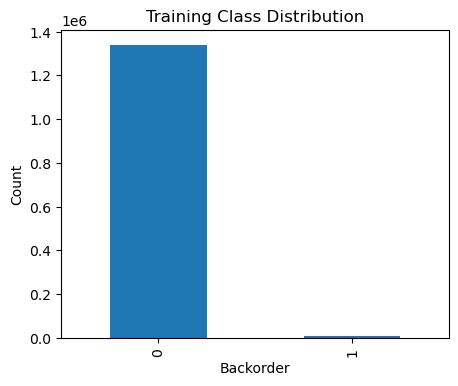

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

y_train_base.value_counts().plot(
    kind="bar"
)

plt.title("Training Class Distribution")
plt.xlabel("Backorder")
plt.ylabel("Count")

plt.show()

## Class Balancing

### Random UnderSampling

In [25]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [26]:
# Apply Random UnderSampling to the baseline training data

rus = RandomUnderSampler(
    random_state=42
)

X_train_base_under, y_train_base_under = rus.fit_resample(
    X_train_base,
    y_train_base
)

In [27]:
# Apply Random UnderSampling to the engineered training data

X_train_eng_under, y_train_eng_under = rus.fit_resample(
    X_train_eng,
    y_train_eng
)

In [28]:
print("Baseline")

print(y_train_base_under.value_counts())

Baseline
went_on_backorder
0    9034
1    9034
Name: count, dtype: int64


In [29]:
print("Engineered")

print(y_train_eng_under.value_counts())

Engineered
went_on_backorder
0    9034
1    9034
Name: count, dtype: int64


### SMOTE

In [30]:
# Apply SMOTE to the baseline training data

smote = SMOTE(
    random_state=42
)

X_train_base_smote, y_train_base_smote = smote.fit_resample(
    X_train_base,
    y_train_base
)

In [31]:
# Apply SMOTE to the engineered training data

X_train_eng_smote, y_train_eng_smote = smote.fit_resample(
    X_train_eng,
    y_train_eng
)

In [32]:
print("Baseline")

print(y_train_base_smote.value_counts())

Baseline
went_on_backorder
0    1341254
1    1341254
Name: count, dtype: int64


In [33]:
print("Engineered")

print(y_train_eng_smote.value_counts())

Engineered
went_on_backorder
0    1341254
1    1341254
Name: count, dtype: int64


### Compare undersampling and SMOTE

In [34]:
balance_summary = {
    "Original": y_train_base.value_counts(),
    "UnderSampling": y_train_base_under.value_counts(),
    "SMOTE": y_train_base_smote.value_counts()
}

pd.DataFrame(balance_summary)

,Original,UnderSampling,SMOTE
went_on_backorder,,,
0,1341254,9034,1341254
1,9034,9034,1341254


## Feature selection

### Separate variable types

In [35]:
# Review numerical features in the baseline dataset

baseline_numeric = X_train_base.select_dtypes(
    include=["number"]
).columns.tolist()

In [36]:
print("Baseline numerical features:")
print(baseline_numeric)

Baseline numerical features:
['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']


In [37]:
print(f"Total: {len(baseline_numeric)}")

Total: 21


In [38]:
# Review numerical features in the engineered dataset

engineered_numeric = X_train_eng.select_dtypes(
    include=["number"]
).columns.tolist()

In [39]:
print("Engineered numerical features:")
print(engineered_numeric)

Engineered numerical features:
['national_inv', 'lead_time', 'in_transit_qty', 'forecast_3_month', 'forecast_6_month', 'forecast_9_month', 'sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month', 'min_bank', 'potential_issue', 'pieces_past_due', 'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'perf_6_month_avg_missing', 'perf_12_month_avg_missing', 'operational_risk_score', 'inventory_coverage', 'zero_3m_forecast', 'inventory_gap']


In [40]:
print(f"Total: {len(engineered_numeric)}")

Total: 27


### Train random forest

Estimate feature importance using the original engineered training data, to evaluate the intrinsic predictive value of each feature before any resampling method modifies the class distribution.
    

In [41]:
# Train a temporary Random Forest to estimate feature importance

rf_feature_selection = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_feature_selection.fit(
    X_train_eng,
    y_train_eng
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train_eng.columns,
        "Importance": rf_feature_selection.feature_importances_
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
14,perf_12_month_avg,0.0973
13,perf_6_month_avg,0.0927
9,sales_9_month,0.0812
5,forecast_9_month,0.0729
8,sales_6_month,0.0696
26,inventory_gap,0.0665
4,forecast_6_month,0.0657
7,sales_3_month,0.0627
0,national_inv,0.0535
24,inventory_coverage,0.0530


In [43]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train_eng.columns,
        "Importance": rf_feature_selection.feature_importances_
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
14,perf_12_month_avg,0.0973
13,perf_6_month_avg,0.0927
9,sales_9_month,0.0812
5,forecast_9_month,0.0729
8,sales_6_month,0.0696
26,inventory_gap,0.0665
4,forecast_6_month,0.0657
7,sales_3_month,0.0627
0,national_inv,0.0535
24,inventory_coverage,0.0530


In [44]:
feature_importance.tail(10)

,Feature,Importance
12,pieces_past_due,0.0117
18,ppap_risk,0.0095
16,deck_risk,0.0082
19,stop_auto_buy,0.0043
21,perf_6_month_avg_missing,0.0024
22,perf_12_month_avg_missing,0.0022
25,zero_3m_forecast,0.0021
11,potential_issue,0.0009
17,oe_constraint,0.0003
20,rev_stop,0.0000


<Figure size 800x800 with 0 Axes>

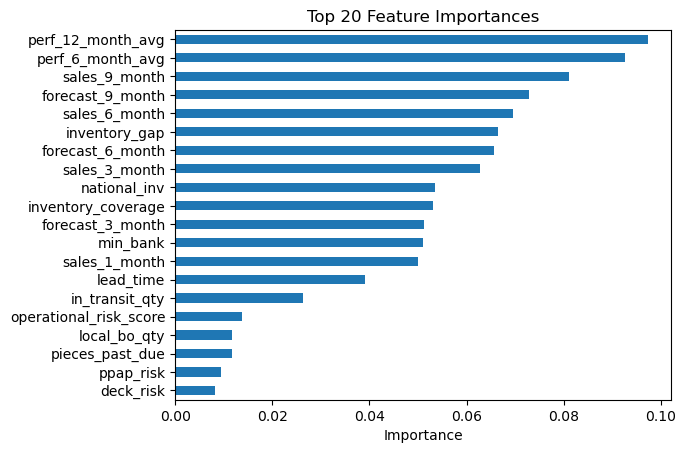

In [45]:
plt.figure(figsize=(8,8))

(
    feature_importance
    .head(20)
    .sort_values("Importance")
    .plot(
        x="Feature",
        y="Importance",
        kind="barh",
        legend=False
    )
)

plt.title("Top 20 Feature Importances")

plt.xlabel("Importance")

plt.ylabel("")

plt.show()

Since *rev_stop* has 0 importance, I eliminate it from all the datasets before doing the different models of machien learning.

In [46]:
# Remove rev_stop from the engineered datasets after feature selection
columns_to_drop = ["rev_stop"]

In [47]:
# Remove selected feature from engineered train and validation sets
X_train_eng = X_train_eng.drop(columns=columns_to_drop)

In [48]:
X_valid_eng = X_valid_eng.drop(columns=columns_to_drop)

In [49]:
# Remove selected feature from balanced engineered training sets
X_train_eng_under = X_train_eng_under.drop(columns=columns_to_drop)

In [50]:
X_train_eng_smote = X_train_eng_smote.drop(columns=columns_to_drop)

In [51]:
# Confirm rev_stop was removed from all engineered modeling datasets
print("Train engineered:", "rev_stop" in X_train_eng.columns)
print("Validation engineered:", "rev_stop" in X_valid_eng.columns)
print("UnderSampling engineered:", "rev_stop" in X_train_eng_under.columns)
print("SMOTE engineered:", "rev_stop" in X_train_eng_smote.columns)

Train engineered: False
Validation engineered: False
UnderSampling engineered: False
SMOTE engineered: False


## Feature Scaling

Logistic Regression is sensitive to feature magnitude, so numerical features are standardised before training.

In [52]:
# Identify binary features in the baseline dataset
binary_features_base = [
    column
    for column in X_train_base.columns
    if set(X_train_base[column].unique()).issubset({0, 1})
]

binary_features_base

['potential_issue',
 'deck_risk',
 'oe_constraint',
 'ppap_risk',
 'stop_auto_buy',
 'rev_stop']

In [53]:
# Identify continuous numerical features in the baseline dataset
continuous_features_base = [
    column
    for column in X_train_base.columns
    if column not in binary_features_base
]

continuous_features_base

['national_inv',
 'lead_time',
 'in_transit_qty',
 'forecast_3_month',
 'forecast_6_month',
 'forecast_9_month',
 'sales_1_month',
 'sales_3_month',
 'sales_6_month',
 'sales_9_month',
 'min_bank',
 'pieces_past_due',
 'perf_6_month_avg',
 'perf_12_month_avg',
 'local_bo_qty']

In [54]:
# Identify binary features in the engineered dataset
binary_features_eng = [
    column
    for column in X_train_eng.columns
    if set(X_train_eng[column].unique()).issubset({0, 1})
]

binary_features_eng

['potential_issue',
 'deck_risk',
 'oe_constraint',
 'ppap_risk',
 'stop_auto_buy',
 'perf_6_month_avg_missing',
 'perf_12_month_avg_missing',
 'zero_3m_forecast']

In [55]:
# Identify continuous numerical features in the engineered dataset
continuous_features_eng = [
    column
    for column in X_train_eng.columns
    if column not in binary_features_eng
]

continuous_features_eng

['national_inv',
 'lead_time',
 'in_transit_qty',
 'forecast_3_month',
 'forecast_6_month',
 'forecast_9_month',
 'sales_1_month',
 'sales_3_month',
 'sales_6_month',
 'sales_9_month',
 'min_bank',
 'pieces_past_due',
 'perf_6_month_avg',
 'perf_12_month_avg',
 'local_bo_qty',
 'operational_risk_score',
 'inventory_coverage',
 'inventory_gap']

In [56]:
print("Baseline binary:", len(binary_features_base))
print("Baseline continuous:", len(continuous_features_base))

Baseline binary: 6
Baseline continuous: 15


In [57]:
print("Engineered binary:", len(binary_features_eng))
print("Engineered continuous:", len(continuous_features_eng))

Engineered binary: 8
Engineered continuous: 18


In [58]:
# Create independent scalers for baseline and engineered datasets
scaler_base = StandardScaler()
scaler_eng = StandardScaler()

In [59]:
# Learn scaling parameters only from the original training data
scaler_base.fit(
    X_train_base[continuous_features_base]
)

,copy,True
,with_mean,True
,with_std,True


In [60]:
scaler_eng.fit(
    X_train_eng[continuous_features_eng]
)

,copy,True
,with_mean,True
,with_std,True


In [61]:
# Create scaled copies for Logistic Regression
X_train_base_under_scaled = X_train_base_under.copy()
X_valid_base_scaled = X_valid_base.copy()

In [62]:
X_train_base_under_scaled[continuous_features_base] = (
    scaler_base.transform(
        X_train_base_under[continuous_features_base]
    )
)

In [63]:
X_valid_base_scaled[continuous_features_base] = (
    scaler_base.transform(
        X_valid_base[continuous_features_base]
    )
)

In [64]:
# Create scaled copies for engineered UnderSampling
X_train_eng_under_scaled = X_train_eng_under.copy()
X_valid_eng_scaled = X_valid_eng.copy()

In [65]:
X_train_eng_under_scaled[continuous_features_eng] = (
    scaler_eng.transform(
        X_train_eng_under[continuous_features_eng]
    )
)

In [66]:
X_valid_eng_scaled[continuous_features_eng] = (
    scaler_eng.transform(
        X_valid_eng[continuous_features_eng]
    )
)

In [67]:
# Scale the original baseline training data before applying SMOTE
X_train_base_scaled = X_train_base.copy()

In [68]:
X_train_base_scaled[continuous_features_base] = (
    scaler_base.transform(
        X_train_base[continuous_features_base]
    )
)

In [69]:
# Apply SMOTE after scaling for Logistic Regression
smote_lr_base = SMOTE(
    random_state=42
)

In [70]:
X_train_base_smote_scaled, y_train_base_smote_scaled = (
    smote_lr_base.fit_resample(
        X_train_base_scaled,
        y_train_base
    )
)

In [71]:
# Scale the original engineered training data before applying SMOTE
X_train_eng_scaled = X_train_eng.copy()

In [72]:
X_train_eng_scaled[continuous_features_eng] = (
    scaler_eng.transform(
        X_train_eng[continuous_features_eng]
    )
)

In [73]:
# Apply SMOTE after scaling for Logistic Regression
smote_lr_eng = SMOTE(
    random_state=42
)

In [74]:
X_train_eng_smote_scaled, y_train_eng_smote_scaled = (
    smote_lr_eng.fit_resample(
        X_train_eng_scaled,
        y_train_eng
    )
)

In [75]:
# Check scaled continuous features
X_train_base_under_scaled[
    continuous_features_base
].describe().loc[["mean", "std"]]

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
mean,-0.0095,-0.1053,-0.0089,0.0008,-0.0026,-0.0038,-0.0024,-0.0038,-0.0050,-0.0053,-0.0091,0.0008,-0.1618,-0.1585,0.0548
std,0.1306,0.8461,0.8911,0.8890,0.8682,0.8827,0.9730,1.1200,1.1718,1.1742,0.7397,0.1259,1.1481,1.1395,1.2909


In [76]:
# Confirm that binary features were not scaled
for column in binary_features_base:
    print(
        column,
        X_train_base_under_scaled[column].unique()
    )

potential_issue [0 1]
deck_risk [0 1]
oe_constraint [0 1]
ppap_risk [0 1]
stop_auto_buy [1 0]
rev_stop [0 1]


## Logistic Regression

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [78]:
# Create reusable model evaluation function

def evaluate_model(
    model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    model_name
):
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "ROC_AUC": roc_auc_score(y_valid, y_prob),
        "PR_AUC": average_precision_score(y_valid, y_prob)
    }

    return results

In [79]:
# Logistic Regression - Baseline + UnderSampling

lr_base_under = LogisticRegression(
    random_state=42,
    max_iter=1000
)

results_lr_base_under = evaluate_model(
    lr_base_under,
    X_train_base_under_scaled,
    y_train_base_under,
    X_valid_base_scaled,
    y_valid_base,
    "Logistic Regression - Baseline - UnderSampling"
)

results_lr_base_under

{'Model': 'Logistic Regression - Baseline - UnderSampling',
 'Accuracy': 0.6606768333866553,
 'Precision': 0.01181687752706404,
 'Recall': 0.601593625498008,
 'F1': 0.02317846909537454,
 'ROC_AUC': 0.6969314982013719,
 'PR_AUC': 0.016673758200712603}

In [80]:
# Logistic Regression - Engineered + UnderSampling

lr_eng_under = LogisticRegression(
    random_state=42,
    max_iter=1000
)

results_lr_eng_under = evaluate_model(
    lr_eng_under,
    X_train_eng_under_scaled,
    y_train_eng_under,
    X_valid_eng_scaled,
    y_valid_eng,
    "Logistic Regression - Engineered - UnderSampling"
)

results_lr_eng_under

{'Model': 'Logistic Regression - Engineered - UnderSampling',
 'Accuracy': 0.7959368668017489,
 'Precision': 0.026669129452551114,
 'Recall': 0.8308986277113767,
 'F1': 0.0516795154185022,
 'ROC_AUC': 0.8795408887335248,
 'PR_AUC': 0.05516180379083572}

In [81]:
# Logistic Regression - Baseline + SMOTE

lr_base_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

results_lr_base_smote = evaluate_model(
    lr_base_smote,
    X_train_base_smote_scaled,
    y_train_base_smote_scaled,
    X_valid_base_scaled,
    y_valid_base,
    "Logistic Regression - Baseline - SMOTE"
)

results_lr_base_smote

{'Model': 'Logistic Regression - Baseline - SMOTE',
 'Accuracy': 0.649328143329423,
 'Precision': 0.013279010110155426,
 'Recall': 0.701195219123506,
 'F1': 0.02606442058496853,
 'ROC_AUC': 0.7551275504658312,
 'PR_AUC': 0.022454581173036652}

In [82]:
# Logistic Regression - Engineered + SMOTE

lr_eng_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

results_lr_eng_smote = evaluate_model(
    lr_eng_smote,
    X_train_eng_smote_scaled,
    y_train_eng_smote_scaled,
    X_valid_eng_scaled,
    y_valid_eng,
    "Logistic Regression - Engineered - SMOTE"
)

results_lr_eng_smote

{'Model': 'Logistic Regression - Engineered - SMOTE',
 'Accuracy': 0.8292601282096856,
 'Precision': 0.031235186564637366,
 'Recall': 0.8167330677290837,
 'F1': 0.060169256608019306,
 'ROC_AUC': 0.8856951724399363,
 'PR_AUC': 0.06171264284899588}

In [83]:
# Compare Logistic Regression experiments

lr_results = pd.DataFrame([
    results_lr_base_under,
    results_lr_base_smote,
    results_lr_eng_under,
    results_lr_eng_smote
])

In [84]:

lr_results.sort_values(
    by="PR_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,Logistic Regression - Engineered - SMOTE,0.8293,0.0312,0.8167,0.0602,0.8857,0.0617
2,Logistic Regression - Engineered - UnderSampling,0.7959,0.0267,0.8309,0.0517,0.8795,0.0552
1,Logistic Regression - Baseline - SMOTE,0.6493,0.0133,0.7012,0.0261,0.7551,0.0225
0,Logistic Regression - Baseline - UnderSampling,0.6607,0.0118,0.6016,0.0232,0.6969,0.0167


### Conclussions

The engineered datasets clearly outperform the baseline datasets across the main evaluation metrics, confirming that the additional features provide useful predictive information.

Among the four experiments, Engineered + SMOTE achieves the strongest overall performance, with the highest Precision, F1-score, ROC-AUC and PR-AUC. Engineered + UnderSampling achieves a slightly higher Recall, identifying approximately 83% of actual backorders.

However, Precision remains low across all configurations. This indicates that, although the models identify a large proportion of actual backorders, they also generate a considerable number of false positives.

## Decision tree

In [85]:
# Decision Tree - Baseline + UnderSampling

dt_base_under = DecisionTreeClassifier(
    random_state=42
)

results_dt_base_under = evaluate_model(
    dt_base_under,
    X_train_base_under,
    y_train_base_under,
    X_valid_base,
    y_valid_base,
    "Decision Tree - Baseline - UnderSampling"
)

In [86]:
# Decision Tree - Baseline + SMOTE

dt_base_smote = DecisionTreeClassifier(
    random_state=42
)

results_dt_base_smote = evaluate_model(
    dt_base_smote,
    X_train_base_smote,
    y_train_base_smote,
    X_valid_base,
    y_valid_base,
    "Decision Tree - Baseline - SMOTE"
)

In [87]:
# Decision Tree - Engineered + UnderSampling

dt_eng_under = DecisionTreeClassifier(
    random_state=42
)

results_dt_eng_under = evaluate_model(
    dt_eng_under,
    X_train_eng_under,
    y_train_eng_under,
    X_valid_eng,
    y_valid_eng,
    "Decision Tree - Engineered - UnderSampling"
)

In [88]:
# Decision Tree - Engineered + SMOTE

dt_eng_smote = DecisionTreeClassifier(
    random_state=42
)

results_dt_eng_smote = evaluate_model(
    dt_eng_smote,
    X_train_eng_smote,
    y_train_eng_smote,
    X_valid_eng,
    y_valid_eng,
    "Decision Tree - Engineered - SMOTE"
)

In [89]:
# Compare Decision Tree experiments

dt_results = pd.DataFrame([
    results_dt_base_under,
    results_dt_base_smote,
    results_dt_eng_under,
    results_dt_eng_smote
])

dt_results.sort_values(
    by="PR_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,Decision Tree - Engineered - SMOTE,0.9879,0.2706,0.4732,0.3443,0.7407,0.1531
1,Decision Tree - Baseline - SMOTE,0.9882,0.2677,0.4440,0.3340,0.7257,0.1438
0,Decision Tree - Baseline - UnderSampling,0.8592,0.0403,0.8796,0.0771,0.8722,0.0367
2,Decision Tree - Engineered - UnderSampling,0.8579,0.0398,0.8743,0.0761,0.8689,0.0361


### Conclussions

SMOTE provides a substantially better precision–recall trade-off than Random UnderSampling. The engineered SMOTE dataset achieves the highest PR-AUC (0.1531) and F1-score (0.3443), outperforming the baseline SMOTE version. 

UnderSampling produces substantially higher recall (~0.88), but at the cost of very low precision (~0.04), suggesting a large number of false-positive backorder predictions. Therefore, Engineered + SMOTE is currently the strongest Decision Tree configuration.

## Random forest

In [90]:
# Random Forest - Baseline + UnderSampling

rf_base_under = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

results_rf_base_under = evaluate_model(
    rf_base_under,
    X_train_base_under,
    y_train_base_under,
    X_valid_base,
    y_valid_base,
    "Random Forest - Baseline - UnderSampling"
)

results_rf_base_under

{'Model': 'Random Forest - Baseline - UnderSampling',
 'Accuracy': 0.887997227258185,
 'Precision': 0.05354900286331441,
 'Recall': 0.9437804338202744,
 'F1': 0.10134765764266869,
 'ROC_AUC': 0.9687213059963569,
 'PR_AUC': 0.22061797346264003}

In [91]:
# Random Forest - Baseline + SMOTE

rf_base_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

results_rf_base_smote = evaluate_model(
    rf_base_smote,
    X_train_base_smote,
    y_train_base_smote,
    X_valid_base,
    y_valid_base,
    "Random Forest - Baseline - SMOTE"
)

results_rf_base_smote

{'Model': 'Random Forest - Baseline - SMOTE',
 'Accuracy': 0.9930266728283151,
 'Precision': 0.47897299690128375,
 'Recall': 0.47897299690128375,
 'F1': 0.47897299690128375,
 'ROC_AUC': 0.9677487816854373,
 'PR_AUC': 0.41289919797510133}

In [92]:
# Random Forest - Engineered + UnderSampling

rf_eng_under = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

results_rf_eng_under = evaluate_model(
    rf_eng_under,
    X_train_eng_under,
    y_train_eng_under,
    X_valid_eng,
    y_valid_eng,
    "Random Forest - Engineered - UnderSampling"
)

results_rf_eng_under

{'Model': 'Random Forest - Engineered - UnderSampling',
 'Accuracy': 0.8859917291718508,
 'Precision': 0.05223345610955924,
 'Recall': 0.935369632580788,
 'F1': 0.09894174939127177,
 'ROC_AUC': 0.9670650086163507,
 'PR_AUC': 0.20813174577434113}

In [93]:
# Random Forest - Engineered + SMOTE

rf_eng_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

results_rf_eng_smote = evaluate_model(
    rf_eng_smote,
    X_train_eng_smote,
    y_train_eng_smote,
    X_valid_eng,
    y_valid_eng,
    "Random Forest - Engineered - SMOTE"
)

results_rf_eng_smote

{'Model': 'Random Forest - Engineered - SMOTE',
 'Accuracy': 0.9927689500314008,
 'Precision': 0.4622093023255814,
 'Recall': 0.49269588313413015,
 'F1': 0.47696593100492823,
 'ROC_AUC': 0.967288874957286,
 'PR_AUC': 0.4063127691410459}

In [94]:
# Compare Random Forest experiments

rf_results = pd.DataFrame([
    results_rf_base_under,
    results_rf_base_smote,
    results_rf_eng_under,
    results_rf_eng_smote
])

In [95]:
rf_results.sort_values(
    by="PR_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Random Forest - Baseline - SMOTE,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129
3,Random Forest - Engineered - SMOTE,0.9928,0.4622,0.4927,0.4770,0.9673,0.4063
0,Random Forest - Baseline - UnderSampling,0.8880,0.0535,0.9438,0.1013,0.9687,0.2206
2,Random Forest - Engineered - UnderSampling,0.8860,0.0522,0.9354,0.0989,0.9671,0.2081


## Conclussions

SMOTE substantially outperforms Random UnderSampling in terms of PR-AUC and F1-score. The Baseline + SMOTE configuration achieves the highest PR-AUC (0.4129) and F1-score (0.4790), slightly outperforming the Engineered + SMOTE dataset.

Although the engineered version provides marginally higher recall, the additional features do not improve the overall precision-recall trade-off. Therefore, the Baseline + SMOTE configuration is currently the strongest Random Forest candidate.

## Model comparison

Given the severe class imbalance, PR-AUC is used as the primary model-selection metric. Recall, precision and F1-score are also considered to evaluate the operational trade-off between detecting backorders and generating false-positive alerts.

In [96]:
# Combine all model results

all_results = pd.concat([
    lr_results,
    dt_results,
    rf_results
], ignore_index=True)

all_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression - Baseline - UnderSampling,0.6607,0.0118,0.6016,0.0232,0.6969,0.0167
1,Logistic Regression - Baseline - SMOTE,0.6493,0.0133,0.7012,0.0261,0.7551,0.0225
2,Logistic Regression - Engineered - UnderSampling,0.7959,0.0267,0.8309,0.0517,0.8795,0.0552
3,Logistic Regression - Engineered - SMOTE,0.8293,0.0312,0.8167,0.0602,0.8857,0.0617
4,Decision Tree - Baseline - UnderSampling,0.8592,0.0403,0.8796,0.0771,0.8722,0.0367
5,Decision Tree - Baseline - SMOTE,0.9882,0.2677,0.4440,0.3340,0.7257,0.1438
6,Decision Tree - Engineered - UnderSampling,0.8579,0.0398,0.8743,0.0761,0.8689,0.0361
7,Decision Tree - Engineered - SMOTE,0.9879,0.2706,0.4732,0.3443,0.7407,0.1531
8,Random Forest - Baseline - UnderSampling,0.8880,0.0535,0.9438,0.1013,0.9687,0.2206
9,Random Forest - Baseline - SMOTE,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129


In [97]:
# Rank all model configurations by PR-AUC

all_results_sorted = (
    all_results
    .sort_values(
        by="PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

all_results_sorted

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Baseline - SMOTE,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129
1,Random Forest - Engineered - SMOTE,0.9928,0.4622,0.4927,0.4770,0.9673,0.4063
2,Random Forest - Baseline - UnderSampling,0.8880,0.0535,0.9438,0.1013,0.9687,0.2206
3,Random Forest - Engineered - UnderSampling,0.8860,0.0522,0.9354,0.0989,0.9671,0.2081
4,Decision Tree - Engineered - SMOTE,0.9879,0.2706,0.4732,0.3443,0.7407,0.1531
5,Decision Tree - Baseline - SMOTE,0.9882,0.2677,0.4440,0.3340,0.7257,0.1438
6,Logistic Regression - Engineered - SMOTE,0.8293,0.0312,0.8167,0.0602,0.8857,0.0617
7,Logistic Regression - Engineered - UnderSampling,0.7959,0.0267,0.8309,0.0517,0.8795,0.0552
8,Decision Tree - Baseline - UnderSampling,0.8592,0.0403,0.8796,0.0771,0.8722,0.0367
9,Decision Tree - Engineered - UnderSampling,0.8579,0.0398,0.8743,0.0761,0.8689,0.0361


### Conclussions

Random Forest clearly outperformed Logistic Regression and Decision Tree across the evaluated configurations.

The **Baseline + SMOTE** configuration achieved the highest PR-AUC (0.4129) and F1-score (0.4790), providing the strongest overall balance between identifying backorders and limiting false-positive predictions.

The **Baseline + UnderSampling** configuration achieved substantially higher recall (0.9438), although with considerably lower precision (0.0535). This configuration is therefore retained as a high-recall alternative, since missing a potential backorder may carry a higher operational cost than investigating a false-positive alert.

The engineered datasets did not improve the overall Random Forest performance, suggesting that the model was already able to capture most of the relevant relationships from the original predictors.

## Hyperparameter tuning

In [102]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [103]:
# Create pipeline so SMOTE is applied only inside each training fold

rf_smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

In [104]:
# Reduced search space for efficient hyperparameter tuning

param_distributions = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [10, 20, None],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt"]
}

In [105]:
# Stratified cross-validation preserves the class distribution

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [106]:
# Randomized search optimized for PR-AUC

rf_smote_search = RandomizedSearchCV(
    estimator=rf_smote_pipeline,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=2,
    verbose=2
)

In [107]:
print("Original training:", X_train_base.shape)
print("Original target:", y_train_base.shape)

Original training: (1350288, 21)
Original target: (1350288,)


In [108]:
print("Class distribution:")
print(y_train_base.value_counts())

Class distribution:
went_on_backorder
0    1341254
1       9034
Name: count, dtype: int64


In [109]:
print("Class proportions:")
print(y_train_base.value_counts(normalize=True))

Class proportions:
went_on_backorder
0   0.9933
1   0.0067
Name: proportion, dtype: float64


In [110]:
# Create a stratified sample for hyperparameter tuning

from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_base,
    y_train_base,
    train_size=0.20,
    stratify=y_train_base,
    random_state=42
)

In [111]:
print("Tuning sample:", X_tune.shape)
print("Class distribution:")
print(y_tune.value_counts())

Tuning sample: (270057, 21)
Class distribution:
went_on_backorder
0    268250
1      1807
Name: count, dtype: int64


In [112]:
print("Class proportions:")
print(y_tune.value_counts(normalize=True))

Class proportions:
went_on_backorder
0   0.9933
1   0.0067
Name: proportion, dtype: float64


In [113]:
# Run RandomizedSearchCV on the stratified tuning sample

rf_smote_search.fit(
    X_tune,
    y_tune
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'rf__max_depth': [10, 20, ...], 'rf__max_features': ['sqrt'], 'rf__min_samples_leaf': [1, 2], 'rf__min_samples_split': [2, 5], ...}"
,n_iter,6
,scoring,'average_precision'
,n_jobs,2
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [114]:
# Review best hyperparameters

print("Best parameters:")
print(rf_smote_search.best_params_)

Best parameters:
{'rf__n_estimators': 100, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': None}


In [115]:
print("Best CV PR-AUC:")
print(rf_smote_search.best_score_)

Best CV PR-AUC:
0.18712970379232674


In [116]:
# Retrieve the best tuned SMOTE + Random Forest pipeline

best_rf_smote = rf_smote_search.best_estimator_

best_rf_smote

,steps,"[('smote', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [117]:
# Refit the tuned pipeline using the full original training set

best_rf_smote.fit(
    X_train_base,
    y_train_base
)

,steps,"[('smote', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [118]:
# Evaluate tuned Random Forest using the full training set

results_rf_base_smote_tuned = evaluate_model(
    best_rf_smote,
    X_train_base,
    y_train_base,
    X_valid_base,
    y_valid_base,
    "Random Forest - Baseline - SMOTE - Tuned"
)

results_rf_base_smote_tuned

{'Model': 'Random Forest - Baseline - SMOTE - Tuned',
 'Accuracy': 0.9930266728283151,
 'Precision': 0.47897299690128375,
 'Recall': 0.47897299690128375,
 'F1': 0.47897299690128375,
 'ROC_AUC': 0.9677487810253471,
 'PR_AUC': 0.41289918840300643}

In [119]:
# Compare default and tuned Random Forest

rf_tuning_comparison = pd.DataFrame([
    results_rf_base_smote,
    results_rf_base_smote_tuned
])

rf_tuning_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Baseline - SMOTE,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129
1,Random Forest - Baseline - SMOTE - Tuned,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129


## Conclussions

RandomizedSearchCV was used to optimize the best-performing model configuration using PR-AUC as the scoring metric.

The tuned Random Forest produced virtually identical validation performance to the default Random Forest, with a PR-AUC of approximately 0.413 in both cases.

## Refined Hyperparameter Tuning

A second, more targeted search will be performed to explore whether moderate regularization can improve generalization.

The search focuses on tree depth, minimum samples per split and leaf, and the number of features considered at each split.

The same stratified tuning sample is reused to keep computation manageable.

In [120]:
# Define a more targeted hyperparameter search space

param_distributions_refined = {
    "rf__n_estimators": [100, 150, 200],
    "rf__max_depth": [None, 15, 25, 35],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", 0.5]
}

In [121]:
# Create refined randomized search optimized for PR-AUC

rf_smote_search_refined = RandomizedSearchCV(
    estimator=rf_smote_pipeline,
    param_distributions=param_distributions_refined,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=2,
    verbose=2
)

In [122]:
# Run refined tuning on the stratified sample

rf_smote_search_refined.fit(
    X_tune,
    y_tune
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END rf__max_depth=35, rf__max_features=0.5, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=100; total time= 1.2min
[CV] END rf__max_depth=35, rf__max_features=0.5, rf__min_samples_leaf=2, rf__min_samples_split=5, rf__n_estimators=100; total time= 1.1min
[CV] END rf__max_depth=35, rf__max_features=0.5, rf__min_samples_leaf=4, rf__min_samples_split=10, rf__n_estimators=100; total time= 1.1min
[CV] END rf__max_depth=25, rf__max_features=0.5, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=100; total time= 1.1min
[CV] END rf__max_depth=25, rf__max_features=0.5, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=100; total time= 1.1min
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=10, rf__n_estimators=100; total time=  30.8s
[CV] END rf__max_depth=None, rf__max_features=sqrt, rf__min_samples_leaf=2, rf__min_samples_split=10

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'rf__max_depth': [None, 15, ...], 'rf__max_features': ['sqrt', 0.5], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,2
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [123]:
# Review best refined hyperparameters

print("Best refined parameters:")
print(rf_smote_search_refined.best_params_)

Best refined parameters:
{'rf__n_estimators': 100, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 35}


In [124]:
print("Best refined CV PR-AUC:")
print(rf_smote_search_refined.best_score_)

Best refined CV PR-AUC:
0.16983781454096125


In [125]:
# Retrieve the best refined SMOTE + Random Forest pipeline

best_rf_smote_refined = (
    rf_smote_search_refined.best_estimator_
)

best_rf_smote_refined

,steps,"[('smote', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,n_estimators,100
,criterion,'gini'
,max_depth,35
,min_samples_split,10


In [126]:
# Evaluate refined Random Forest using the full original training set

results_rf_base_smote_refined = evaluate_model(
    best_rf_smote_refined,
    X_train_base,
    y_train_base,
    X_valid_base,
    y_valid_base,
    "Random Forest - Baseline - SMOTE - Refined"
)

results_rf_base_smote_refined

{'Model': 'Random Forest - Baseline - SMOTE - Refined',
 'Accuracy': 0.9910211747419809,
 'Precision': 0.37277521423862886,
 'Recall': 0.50066401062417,
 'F1': 0.42735688645380693,
 'ROC_AUC': 0.9742811499608738,
 'PR_AUC': 0.3526814088240561}

In [127]:
# Compare default and tuned Random Forest configurations

rf_final_tuning_comparison = pd.DataFrame([
    results_rf_base_smote,
    results_rf_base_smote_tuned,
    results_rf_base_smote_refined
])

rf_final_tuning_comparison.sort_values(
    by="PR_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Baseline - SMOTE,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129
1,Random Forest - Baseline - SMOTE - Tuned,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129
2,Random Forest - Baseline - SMOTE - Refined,0.9910,0.3728,0.5007,0.4274,0.9743,0.3527


## Threshold optimization

In [128]:
# Obtain validation probabilities from the selected model

y_valid_prob = rf_base_smote.predict_proba(
    X_valid_base
)[:, 1]

In [129]:
from sklearn.metrics import precision_recall_curve

In [130]:
# Calculate precision and recall across classification thresholds

precision_values, recall_values, thresholds = precision_recall_curve(
    y_valid_base,
    y_valid_prob
)

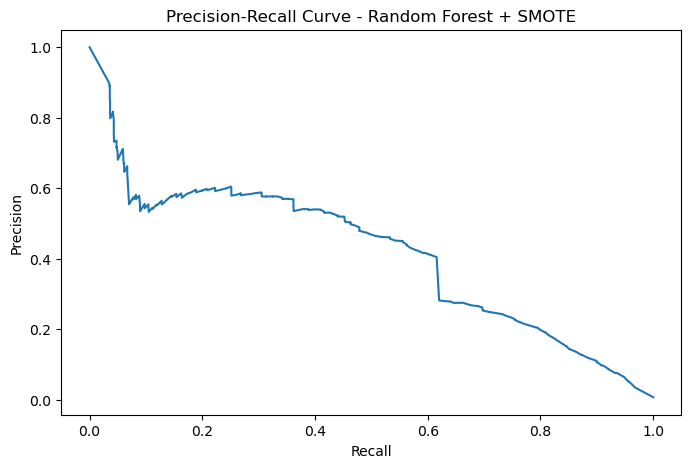

In [131]:
# Visualize the Precision-Recall curve

plt.figure(figsize=(8, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.title("Precision-Recall Curve - Random Forest + SMOTE")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

In [132]:
# Evaluate selected probability thresholds

threshold_options = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

In [133]:
# Compare classification performance across thresholds

threshold_results = []

for threshold in threshold_options:

    y_pred_threshold = (
        y_valid_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid_base,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_valid_base,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_valid_base,
            y_pred_threshold
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.2000,0.2099,0.7813,0.3309
1,0.3000,0.2654,0.6884,0.3831
2,0.4000,0.4208,0.5848,0.4894
3,0.5000,0.4742,0.4892,0.4816
4,0.6000,0.5398,0.3993,0.4590
5,0.7000,0.5857,0.2935,0.3910


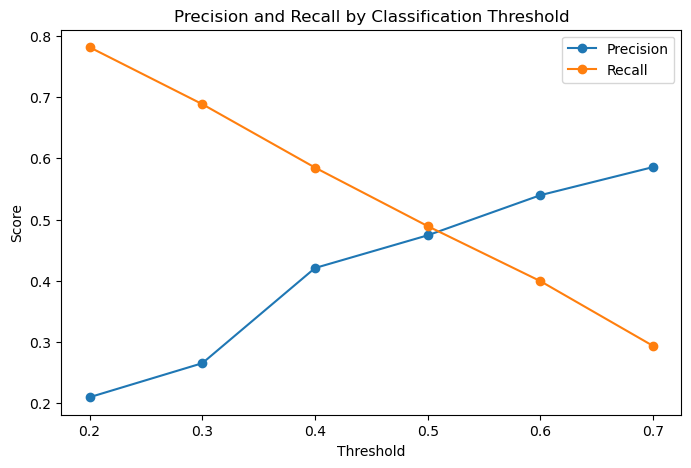

In [134]:
# Visualize precision and recall across thresholds

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.title("Precision and Recall by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.show()

## Final model evaluation on test data

In [138]:
# Separate predictors and target from the untouched baseline test dataset

X_test_base = df_test_baseline.drop(
    columns="went_on_backorder"
)

y_test_base = df_test_baseline[
    "went_on_backorder"
]

In [139]:
# Confirm that training and testing predictors match

print("Training features:", X_train_base.shape[1])

Training features: 21


In [140]:
print("Testing features:", X_test_base.shape[1])

Testing features: 21


In [141]:
print(
    "Columns match:",
    X_train_base.columns.tolist()
    == X_test_base.columns.tolist()
)

Columns match: True


In [142]:
# Review final test dimensions and target distribution

print("Test shape:", X_test_base.shape)

Test shape: (242075, 21)


In [143]:
print("Test target distribution:")
print(y_test_base.value_counts())

Test target distribution:
went_on_backorder
0    239387
1      2688
Name: count, dtype: int64


In [144]:
print("Test target proportions:")
print(
    y_test_base
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Test target proportions:
went_on_backorder
0   98.8900
1    1.1100
Name: proportion, dtype: float64


### Final prediction test data

The selected Random Forest + SMOTE model is now evaluated on the untouched external test dataset.

Predicted probabilities are converted into class predictions using the previously selected **0.40 classification threshold**.

In [145]:
# Generate backorder probabilities on the external test set

y_test_prob = best_rf_smote.predict_proba(
    X_test_base
)[:, 1]

In [146]:
# Convert probabilities into predictions using the selected threshold

final_threshold = 0.40

y_test_pred = (
    y_test_prob >= final_threshold
).astype(int)

In [147]:
# Review predicted class distribution

print("Predicted classes:")
print(
    pd.Series(y_test_pred)
    .value_counts()
)

Predicted classes:
0    240749
1      1326
Name: count, dtype: int64


In [148]:
print("Predicted proportions:")
print(
    pd.Series(y_test_pred)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Predicted proportions:
0   99.4500
1    0.5500
Name: proportion, dtype: float64


In [149]:
# Calculate final performance metrics on the untouched test set

final_test_results = {
    "Accuracy": accuracy_score(
        y_test_base,
        y_test_pred
    ),
    "Precision": precision_score(
        y_test_base,
        y_test_pred
    ),
    "Recall": recall_score(
        y_test_base,
        y_test_pred
    ),
    "F1": f1_score(
        y_test_base,
        y_test_pred
    ),
    "ROC_AUC": roc_auc_score(
        y_test_base,
        y_test_prob
    ),
    "PR_AUC": average_precision_score(
        y_test_base,
        y_test_prob
    )
}

final_test_results

{'Accuracy': 0.9866983372921615,
 'Precision': 0.2993966817496229,
 'Recall': 0.14769345238095238,
 'F1': 0.19780767314399603,
 'ROC_AUC': 0.8618185210459175,
 'PR_AUC': 0.13573559063179985}

### Validation vs Test Performance

The selected model was evaluated on the external test dataset to assess its ability to generalize to unseen data.

The classification threshold of 0.40 was selected exclusively using the validation dataset and was not modified based on test performance.

In [150]:
# Compare validation and external test performance

validation_test_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    "Validation": [
        0.4208,
        0.5848,
        0.4894,
        results_rf_base_smote["ROC_AUC"],
        results_rf_base_smote["PR_AUC"]
    ],
    "Test": [
        final_test_results["Precision"],
        final_test_results["Recall"],
        final_test_results["F1"],
        final_test_results["ROC_AUC"],
        final_test_results["PR_AUC"]
    ]
})

validation_test_comparison

,Metric,Validation,Test
0,Precision,0.4208,0.2994
1,Recall,0.5848,0.1477
2,F1,0.4894,0.1978
3,ROC_AUC,0.9677,0.8618
4,PR_AUC,0.4129,0.1357


In [151]:
# Calculate confusion matrix on the external test set

cm = confusion_matrix(
    y_test_base,
    y_test_pred
)

cm

array([[238458,    929],
       [  2291,    397]])

In [152]:
# Extract confusion matrix values

tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 238458
False Positives: 929
False Negatives: 2291
True Positives: 397


### Distribution Shift Analysis

In [153]:
# Compare key feature distributions between training and testing datasets

key_features = [
    "perf_12_month_avg",
    "perf_6_month_avg",
    "sales_9_month",
    "forecast_9_month",
    "sales_6_month",
    "forecast_6_month",
    "sales_3_month",
    "national_inv",
    "forecast_3_month",
    "min_bank"
]

In [154]:
distribution_comparison = pd.DataFrame({
    "Train_Mean": X_train_base[key_features].mean(),
    "Test_Mean": X_test_base[key_features].mean(),
    "Train_Median": X_train_base[key_features].median(),
    "Test_Median": X_test_base[key_features].median(),
    "Train_Std": X_train_base[key_features].std(),
    "Test_Std": X_test_base[key_features].std()
})

distribution_comparison.round(2)

,Train_Mean,Test_Mean,Train_Median,Test_Median,Train_Std,Test_Std
perf_12_month_avg,0.7800,0.7800,0.8300,0.8300,0.2200,0.2200
perf_6_month_avg,0.7900,0.7800,0.8500,0.8500,0.2300,0.2300
sales_9_month,520.4800,511.7800,4.0000,4.0000,"14,810.7100","13,976.7000"
forecast_9_month,508.3200,508.3000,0.0000,0.0000,"14,618.1900","14,109.7200"
sales_6_month,338.2000,340.4300,2.0000,2.0000,"9,533.6600","9,386.5200"
forecast_6_month,346.4100,348.8100,0.0000,0.0000,"9,949.8700","10,081.8000"
sales_3_month,171.6700,172.1400,1.0000,1.0000,"4,952.1700","5,164.2400"
national_inv,494.7500,499.7500,15.0000,15.0000,"28,813.9100","29,280.3900"
forecast_3_month,178.7300,181.4700,0.0000,0.0000,"5,110.7200","5,648.8700"
min_bank,52.2700,52.8000,0.0000,0.0000,"1,186.1400","1,278.5900"


#### Backorder Profile Stability

Although the overall predictor distributions were similar between the training and external test datasets, model performance decreased substantially.

Therefore, the predictor distributions are compared specifically among actual backorder cases to determine whether the characteristics associated with backorders changed between datasets.

In [155]:
# Compare key feature distributions specifically for actual backorders

train_backorders = X_train_base.loc[
    y_train_base == 1,
    key_features
]

test_backorders = X_test_base.loc[
    y_test_base == 1,
    key_features
]

backorder_profile_comparison = pd.DataFrame({
    "Train_BO_Mean": train_backorders.mean(),
    "Test_BO_Mean": test_backorders.mean(),
    "Train_BO_Median": train_backorders.median(),
    "Test_BO_Median": test_backorders.median()
})

backorder_profile_comparison.round(2)

,Train_BO_Mean,Test_BO_Mean,Train_BO_Median,Test_BO_Median
perf_12_month_avg,0.7000,0.7200,0.7800,0.8000
perf_6_month_avg,0.7100,0.7300,0.8000,0.8200
sales_9_month,201.3800,262.6900,19.0000,21.0000
forecast_9_month,330.8400,531.4900,24.0000,24.0000
sales_6_month,136.4800,183.3900,14.0000,15.0000
forecast_6_month,249.1200,406.6600,19.0000,18.0000
sales_3_month,78.4500,105.5600,8.0000,8.0000
national_inv,20.8900,20.5700,1.0000,2.0000
forecast_3_month,159.5600,248.5600,12.0000,10.0000
min_bank,24.2700,40.4200,0.0000,0.0000


Although the overall feature distributions were broadly similar between training and test data, differences emerged when examining actual backorder cases. 

Test-set backorders showed higher mean sales and forecast values, while their medians remained relatively stable. 

This suggests differences concentrated in the upper part of the distributions rather than a uniform shift across all backorder cases.

#### Missed Backorder Analysis

To better understand the decrease in recall on the external test set, actual backorders correctly identified by the model are compared with backorders that the model failed to detect.

In [156]:
# Identify correctly detected and missed backorders

test_analysis = X_test_base.copy()

test_analysis["actual"] = y_test_base.values
test_analysis["predicted"] = y_test_pred

true_positive_mask = (
    (test_analysis["actual"] == 1) &
    (test_analysis["predicted"] == 1)
)

false_negative_mask = (
    (test_analysis["actual"] == 1) &
    (test_analysis["predicted"] == 0)
)

detected_backorders = test_analysis.loc[
    true_positive_mask,
    key_features
]

missed_backorders = test_analysis.loc[
    false_negative_mask,
    key_features
]

In [157]:
print("Detected backorders:", len(detected_backorders))

Detected backorders: 397


In [158]:
print("Missed backorders:", len(missed_backorders))

Missed backorders: 2291


In [159]:
# Compare detected and missed backorder profiles

missed_backorder_comparison = pd.DataFrame({
    "Detected_Median": detected_backorders.median(),
    "Missed_Median": missed_backorders.median(),
    "Detected_Mean": detected_backorders.mean(),
    "Missed_Mean": missed_backorders.mean()
})

missed_backorder_comparison.round(2)

,Detected_Median,Missed_Median,Detected_Mean,Missed_Mean
perf_12_month_avg,0.7000,0.8100,0.6400,0.7400
perf_6_month_avg,0.7300,0.8300,0.6400,0.7400
sales_9_month,74.0000,16.0000,281.8300,259.3700
forecast_9_month,102.0000,18.0000,340.0800,564.6600
sales_6_month,53.0000,12.0000,200.6600,180.4000
forecast_6_month,74.0000,13.0000,253.0900,433.2700
sales_3_month,31.0000,6.0000,112.1900,104.4200
national_inv,1.0000,2.0000,4.1700,23.4100
forecast_3_month,48.0000,8.0000,166.5100,262.7700
min_bank,3.0000,0.0000,28.3600,42.5000


The external test analysis shows that the model detects backorders more effectively when stronger historical demand signals are present.

Detected backorders had substantially higher median sales and forecast values across the 3-, 6-, and 9-month horizons. In contrast, missed backorders showed higher median 6- and 12-month performance values, suggesting that many false negatives resemble historically reliable items and therefore provide weaker warning signals to the model.

The large differences between means and medians also indicate highly skewed distributions and extreme observations, particularly among missed backorders. Therefore, these results should be interpreted as differences in the typical backorder profile rather than uniform differences across all observations.

Overall, the external test results suggest that the model is better at identifying backorders with clear historical demand and supply-risk patterns, while less obvious backorder cases remain considerably more difficult to detect.

The model demonstrates predictive signal, but external validation reveals that additional work is required before operational deployment, particularly to improve the detection of less obvious backorder cases.

## Boosting Model Experiment

Random Forest provided the strongest performance among the models evaluated so far. However, before moving to the combined-dataset experiment, a boosting-based model is evaluated using the same training and validation framework.

In [161]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [162]:
import xgboost as xgb

print(xgb.__version__)

3.4.0


In [163]:
# Calculate class imbalance ratio from the training data

negative_count = (y_train_base == 0).sum()
positive_count = (y_train_base == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative observations:", negative_count)
print("Positive observations:", positive_count)
print("Scale pos weight:", round(scale_pos_weight, 2))

Negative observations: 1341254
Positive observations: 9034
Scale pos weight: 148.47


In [164]:
# Train XGBoost using class weighting

xgb_base = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=2
)

xgb_base.fit(
    X_train_base,
    y_train_base
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [165]:
# Evaluate XGBoost on the validation set

results_xgb_base = evaluate_model(
    xgb_base,
    X_train_base,
    y_train_base,
    X_valid_base,
    y_valid_base,
    "XGBoost - Baseline - Class Weighted"
)

results_xgb_base

{'Model': 'XGBoost - Baseline - Class Weighted',
 'Accuracy': 0.9109612171625608,
 'Precision': 0.06339134258968399,
 'Recall': 0.8933156263833555,
 'F1': 0.11838207256621594,
 'ROC_AUC': 0.9643401774444575,
 'PR_AUC': 0.2585510207181249}

In [166]:
# Compare XGBoost with the current best Random Forest

boosting_comparison = pd.DataFrame([
    results_rf_base_smote,
    results_xgb_base
])

boosting_comparison.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest - Baseline - SMOTE,0.9930,0.4790,0.4790,0.4790,0.9677,0.4129
1,XGBoost - Baseline - Class Weighted,0.9110,0.0634,0.8933,0.1184,0.9643,0.2586


A boosting-based model was evaluated as an alternative approach for the highly imbalanced classification problem. 

Although XGBoost achieved substantially higher recall, its lower precision and PR-AUC indicated a less favorable overall precision-recall trade-off. Therefore, Random Forest with SMOTE remained the preferred modeling approach.

## Combined dataset experiment

To investigate whether the performance drop observed on the external test set is related to the original dataset split, the original training and testing datasets are combined and redistributed using a new stratified 80/20 split.

SMOTE is applied only to the new training partition to prevent data leakage, while the new test partition remains untouched.

The purpose of this experiment is not to replace the original external test evaluation, but to assess whether model performance becomes more stable when observations from both source datasets are randomly redistributed.

In [232]:
# Combine the complete original baseline training and testing dataset

df_combined = pd.concat(
    [df_train_baseline, df_test_baseline],
    axis=0,
    ignore_index=True
)

print("Combined dataset shape:", df_combined.shape)

Combined dataset shape: (1929935, 22)


In [233]:
# Separate predictors and target from the complete combined dataset

X_combined = df_combined.drop(
    columns="went_on_backorder"
)

y_combined = df_combined[
    "went_on_backorder"
]

print("Combined predictors:", X_combined.shape)
print("Combined target:", y_combined.shape)

Combined predictors: (1929935, 21)
Combined target: (1929935,)


In [234]:
# Review class distribution in the complete combined dataset

print("Combined target distribution:")
print(y_combined.value_counts())

print("\nCombined target proportions:")
print(
    y_combined
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Combined target distribution:
went_on_backorder
0    1915954
1      13981
Name: count, dtype: int64

Combined target proportions:
went_on_backorder
0   99.2800
1    0.7200
Name: proportion, dtype: float64


In [235]:
# Create a new stratified 80/20 split from the complete combined dataset

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined,
    y_combined,
    test_size=0.20,
    stratify=y_combined,
    random_state=42
)

In [236]:
# Review the new development and untouched test dimensions

print("Development shape:", X_train_combined.shape)
print("Untouched test shape:", X_test_combined.shape)

print("Development target shape:", y_train_combined.shape)
print("Untouched test target shape:", y_test_combined.shape)

Development shape: (1543948, 21)
Untouched test shape: (385987, 21)
Development target shape: (1543948,)
Untouched test target shape: (385987,)


In [237]:
# Create an internal validation set from the development partition

X_train_combined_final, X_valid_combined, y_train_combined_final, y_valid_combined = train_test_split(
    X_train_combined,
    y_train_combined,
    test_size=0.20,
    stratify=y_train_combined,
    random_state=42
)

print("Final training shape:", X_train_combined_final.shape)
print("Validation shape:", X_valid_combined.shape)
print("Untouched test shape:", X_test_combined.shape)

Final training shape: (1235158, 21)
Validation shape: (308790, 21)
Untouched test shape: (385987, 21)


In [238]:
# Apply SMOTE only to the final training partition

X_train_combined_smote, y_train_combined_smote = smote.fit_resample(
    X_train_combined_final,
    y_train_combined_final
)

In [239]:
print("Before SMOTE:")
print(y_train_combined_final.value_counts())

Before SMOTE:
went_on_backorder
0    1226210
1       8948
Name: count, dtype: int64


In [240]:
print("After SMOTE:")
print(y_train_combined_smote.value_counts())

After SMOTE:
went_on_backorder
0    1226210
1    1226210
Name: count, dtype: int64


### Random forest on the combined dataset

The Random Forest model is trained on the newly created training partition after applying SMOTE. Performance is first evaluated on the untouched validation partition.

In [241]:
# Train Random Forest on the complete combined SMOTE training dataset

rf_combined_smote = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_combined_smote.fit(
    X_train_combined_smote,
    y_train_combined_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [242]:
# Generate validation probabilities

y_valid_combined_prob = rf_combined_smote.predict_proba(
    X_valid_combined
)[:, 1]

In [243]:
# Generate validation predictions using the default threshold

y_valid_combined_pred = (
    y_valid_combined_prob >= 0.50
).astype(int)

In [244]:
# Evaluate Random Forest on the new validation set

combined_validation_results = {
    "Accuracy": accuracy_score(
        y_valid_combined,
        y_valid_combined_pred
    ),
    "Precision": precision_score(
        y_valid_combined,
        y_valid_combined_pred
    ),
    "Recall": recall_score(
        y_valid_combined,
        y_valid_combined_pred
    ),
    "F1": f1_score(
        y_valid_combined,
        y_valid_combined_pred
    ),
    "ROC_AUC": roc_auc_score(
        y_valid_combined,
        y_valid_combined_prob
    ),
    "PR_AUC": average_precision_score(
        y_valid_combined,
        y_valid_combined_prob
    )
}

combined_validation_results

{'Accuracy': 0.9912497166359014,
 'Precision': 0.3929064947029019,
 'Recall': 0.38131426016987036,
 'F1': 0.3870235934664247,
 'ROC_AUC': 0.9453304511276446,
 'PR_AUC': 0.29976997167485575}

### Classification Threshold Selection

Because the objective is to identify potential backorders while maintaining a reasonable number of false alerts, alternative classification thresholds are evaluated on the validation set.

The final threshold is selected using only validation data. The combined test partition remains untouched until the final evaluation.

In [245]:
# Evaluate classification thresholds

fine_threshold_options = np.arange(
    0.40,
    0.501,
    0.01
)

In [246]:
fine_threshold_results = []

for threshold in fine_threshold_options:

    y_pred_threshold = (
        y_valid_combined_prob >= threshold
    ).astype(int)

    fine_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid_combined,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_valid_combined,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_valid_combined,
            y_pred_threshold
        )
    })

fine_threshold_results = pd.DataFrame(
    fine_threshold_results
)

fine_threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.4000,0.3474,0.4761,0.4017
1,0.4100,0.3544,0.4537,0.3980
2,0.4200,0.3600,0.4448,0.3979
3,0.4300,0.3645,0.4354,0.3968
4,0.4400,0.3677,0.4256,0.3945
5,0.4500,0.3735,0.4166,0.3939
6,0.4600,0.3752,0.4072,0.3906
7,0.4700,0.3791,0.4010,0.3897
8,0.4800,0.3896,0.3929,0.3913
9,0.4900,0.3926,0.3818,0.3871


In [247]:
# Identify the threshold with the highest F1-score

best_fine_threshold = fine_threshold_results.loc[
    fine_threshold_results["F1"].idxmax()
]

best_fine_threshold

Threshold   0.4000
Precision   0.3474
Recall      0.4761
F1          0.4017
Name: 0, dtype: float64

A threshold of **0.40** achieved the highest F1-score (**0.4017**), with a Recall of approximately **47.6%** and a Precision of approximately **34.7%**.

### Final evaluation on the untouched test set

Based exclusively on the validation set, a classification threshold of **0.42**
was selected because it achieved the highest F1-score while maintaining a
balance between precision and recall.

In [251]:
# Generate probabilities on the final untouched test set

y_test_combined_prob = rf_combined_smote.predict_proba(
    X_test_combined
)[:, 1]

In [252]:
# Apply the selected classification threshold

final_combined_threshold = 0.40

y_test_combined_pred = (
    y_test_combined_prob >= final_combined_threshold
).astype(int)

In [253]:
# Calculate final performance on the untouched test set

combined_test_results = {
    "Accuracy": accuracy_score(
        y_test_combined,
        y_test_combined_pred
    ),
    "Precision": precision_score(
        y_test_combined,
        y_test_combined_pred
    ),
    "Recall": recall_score(
        y_test_combined,
        y_test_combined_pred
    ),
    "F1": f1_score(
        y_test_combined,
        y_test_combined_pred
    ),
    "ROC_AUC": roc_auc_score(
        y_test_combined,
        y_test_combined_prob
    ),
    "PR_AUC": average_precision_score(
        y_test_combined,
        y_test_combined_prob
    )
}

combined_test_results

{'Accuracy': 0.9897846300523074,
 'Precision': 0.34990840094216175,
 'Recall': 0.4781831187410587,
 'F1': 0.4041106241499169,
 'ROC_AUC': 0.946858871752228,
 'PR_AUC': 0.3024356178979999}

In [254]:
# Compare validation and final test performance

final_generalization_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],
    "Validation": [
        best_fine_threshold["Precision"],
        best_fine_threshold["Recall"],
        best_fine_threshold["F1"],
        combined_validation_results["ROC_AUC"],
        combined_validation_results["PR_AUC"]
    ],
    "Final_Test": [
        combined_test_results["Precision"],
        combined_test_results["Recall"],
        combined_test_results["F1"],
        combined_test_results["ROC_AUC"],
        combined_test_results["PR_AUC"]
    ]
})

final_generalization_comparison.round(4)

,Metric,Validation,Final_Test
0,Precision,0.3474,0.3499
1,Recall,0.4761,0.4782
2,F1,0.4017,0.4041
3,ROC_AUC,0.9453,0.9469
4,PR_AUC,0.2998,0.3024


The final Random Forest model showed highly consistent performance between the validation and untouched test sets. Using the classification threshold of 0.40 selected exclusively on the validation data, the model achieved an F1-score of 0.4041, a recall of 47.82%, and a precision of 34.99% on the final test set.

The minimal differences between validation and test performance suggest that the model generalizes well to unseen data and shows no substantial evidence of overfitting to the validation set. The final ROC-AUC of 0.9469 indicates strong discrimination between backorder and non-backorder cases, while the PR-AUC of 0.3024 is particularly relevant given the severe class imbalance.

From a supply chain perspective, the model is best interpreted as an early-warning prioritization tool: it can identify approximately 48% of actual backorders while substantially narrowing the number of SKUs that planners need to investigate.

### Final Model Interpretation

The final model is now analyzed to understand its prediction behavior and the
main factors contributing to backorder risk.

In [255]:
# Calculate confusion matrix on the final untouched test set

final_cm = confusion_matrix(
    y_test_combined,
    y_test_combined_pred
)

final_cm

array([[380707,   2484],
       [  1459,   1337]])

In [256]:
# Extract confusion matrix values

tn, fp, fn, tp = final_cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 380707
False Positives: 2484
False Negatives: 1459
True Positives: 1337


In [257]:
# Visualize the final confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

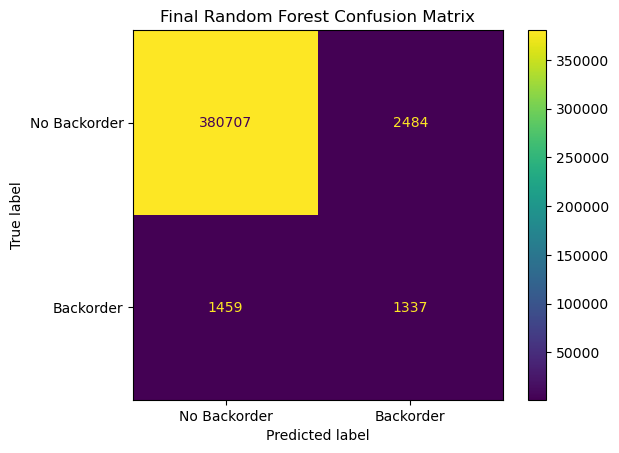

In [258]:
ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Backorder", "Backorder"]
).plot()

plt.title("Final Random Forest Confusion Matrix")
plt.show()

On the untouched test set, the final model correctly identified **1,337 actual backorders**, while **1,459 backorders were missed**.

The model also generated **2,484 false positive alerts**, representing products flagged as potential backorders that did not actually go into backorder.

This reflects the trade-off established during threshold optimization. With the selected classification threshold of **0.40**, the model detects approximately **47.8% of actual backorders**, while maintaining a precision of approximately **35.0%**.

From a supply chain perspective, the model should therefore be interpreted as an **early-warning prioritization tool rather than an automatic decision system**. Predicted backorders can be flagged for additional review by planners, allowing teams to prioritize potentially risky SKUs before taking operational actions.

### Feature importance

In [259]:
# Extract feature importance from the final Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X_train_combined_final.columns,
    "Importance": rf_combined_smote.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,Feature,Importance
0,national_inv,0.2169
1,forecast_3_month,0.1288
2,forecast_6_month,0.1253
3,forecast_9_month,0.0813
4,sales_1_month,0.0596
5,sales_3_month,0.0452
6,sales_9_month,0.0435
7,perf_6_month_avg,0.0432
8,sales_6_month,0.0424
9,perf_12_month_avg,0.0422


In [260]:
# Confirm that feature importances sum to 1

print(
    "Total feature importance:",
    feature_importance["Importance"].sum()
)

Total feature importance: 0.9999999999999999


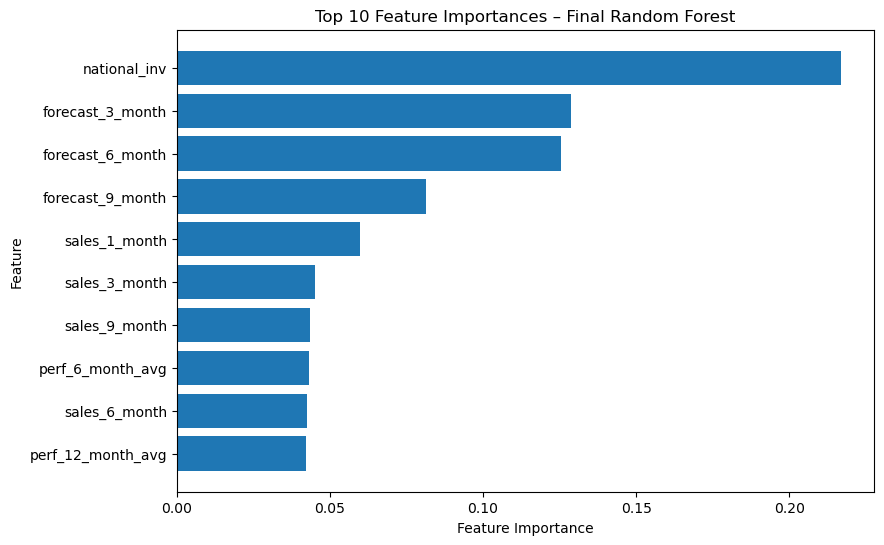

In [261]:
# Visualize the top 10 most important features

top_features = feature_importance.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances – Final Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

Feature importance analysis shows that inventory position and demand-related variables are the main drivers of the model's backorder predictions. 

National inventory is the most influential feature, followed by the 3-, 6-, and 9-month forecasts. Recent and historical sales variables also contribute substantially to the predictions, while operational variables such as lead time, minimum bank, and in-transit quantity provide additional predictive information.

From a supply chain perspective, this suggests that backorder risk is primarily associated with the relationship between available inventory and expected demand, rather than being driven by a single operational constraint.

## Additional experiment - review if there are patterns and if there are families of skus

In [208]:
# Load original SKU and target data for the additional analysis

raw_train_path = "../data/raw/Training_BOP.csv"
raw_test_path = "../data/raw/Testing_BOP.csv"

In [209]:
sku_train = pd.read_csv(
    raw_train_path,
    usecols=["sku", "went_on_backorder"],
    low_memory=False
)

In [210]:
sku_test = pd.read_csv(
    raw_test_path,
    usecols=["sku", "went_on_backorder"],
    low_memory=False
)

In [211]:
print("Raw training:", sku_train.shape)
print("Raw testing:", sku_test.shape)

Raw training: (1687861, 2)
Raw testing: (242076, 2)


In [212]:
#Join both to identify if there are patterns in the SKUs (Families)
sku_analysis = pd.concat(
    [sku_train, sku_test],
    axis=0,
    ignore_index=True
)

sku_analysis["sku"] = (
    sku_analysis["sku"]
    .astype(str)
    .str.replace(".0", "", regex=False)
)

In [213]:
print("Number of observations:", len(sku_analysis))
print("Number of unique SKUs:", sku_analysis["sku"].nunique())

Number of observations: 1929937
Number of unique SKUs: 1929937


In [214]:
print("SKU length distribution:")

print(
    sku_analysis["sku"]
    .str.len()
    .value_counts()
    .sort_index()
)

SKU length distribution:
sku
7     1929935
13          1
14          1
Name: count, dtype: int64


In [215]:
print("Example SKUs:")

print(
    sku_analysis["sku"]
    .head(20)
    .tolist()
)

Example SKUs:
['1026827', '1043384', '1043696', '1043852', '1044048', '1044198', '1044643', '1045098', '1045815', '1045867', '1045918', '1047146', '1047199', '1047661', '1049160', '1049468', '1050390', '1050440', '1117808', '1050856']


In [216]:
# Explore potential SKU groupings based on different prefix lengths

for n_digits in [1, 2, 3, 4]:

    sku_prefix = sku_analysis["sku"].str[:n_digits]

    print(f"\n--- First {n_digits} digit(s) ---")
    print("Number of groups:", sku_prefix.nunique())

    print("Group size summary:")
    print(
        sku_prefix
        .value_counts()
        .describe()
        .round(2)
    )


--- First 1 digit(s) ---
Number of groups: 4
Group size summary:
count         4.0000
mean    482,484.2500
std     365,434.0200
min           2.0000
25%     385,844.7500
50%     520,727.0000
75%     617,366.5000
max     888,481.0000
Name: count, dtype: float64

--- First 2 digit(s) ---
Number of groups: 24
Group size summary:
count        24.0000
mean     80,414.0400
std      38,040.0100
min           1.0000
25%      95,849.7500
50%     100,000.0000
75%     100,000.0000
max     100,000.0000
Name: count, dtype: float64

--- First 3 digit(s) ---
Number of groups: 200
Group size summary:
count      200.0000
mean     9,649.6800
std      1,741.5800
min          1.0000
25%     10,000.0000
50%     10,000.0000
75%     10,000.0000
max     10,000.0000
Name: count, dtype: float64

--- First 4 digit(s) ---
Number of groups: 1957
Group size summary:
count   1,957.0000
mean      986.1700
std       115.4000
min         1.0000
25%     1,000.0000
50%     1,000.0000
75%     1,000.0000
max     1,000.000

In [217]:
# Create candidate SKU family using the first 3 digits

sku_analysis["sku_family_3"] = (
    sku_analysis["sku"]
    .str[:3]
)

In [219]:
# Review original target values

sku_analysis["went_on_backorder"].value_counts(dropna=False)

went_on_backorder
No     1915954
Yes      13981
NaN          2
Name: count, dtype: int64

In [220]:
# Convert raw backorder target to binary values

sku_analysis["backorder_binary"] = (
    sku_analysis["went_on_backorder"]
    .str.strip()
    .str.lower()
    .map({
        "no": 0,
        "yes": 1
    })
)

sku_analysis["backorder_binary"].value_counts(dropna=False)

backorder_binary
0.0000    1915954
1.0000      13981
NaN             2
Name: count, dtype: int64

In [222]:
# Create candidate SKU groups based on the first 3 digits

sku_analysis["sku_prefix_3"] = (
    sku_analysis["sku"]
    .str[:3]
)

In [223]:
# Review backorder behavior across SKU prefixes

prefix_summary = (
    sku_analysis
    .groupby("sku_prefix_3")
    .agg(
        observations=("backorder_binary", "size"),
        backorders=("backorder_binary", "sum"),
        backorder_rate=("backorder_binary", "mean")
    )
    .reset_index()
)

prefix_summary["backorder_rate"] = (
    prefix_summary["backorder_rate"] * 100
)

prefix_summary.head()

,sku_prefix_3,observations,backorders,backorder_rate
0,(16,1,0.0000,NaN
1,(24,1,0.0000,NaN
2,102,1,0.0000,0.0000
3,104,15,0.0000,0.0000
4,105,15,0.0000,0.0000


In [224]:
# Focus on sufficiently represented SKU prefixes

prefix_summary_filtered = (
    prefix_summary[
        prefix_summary["observations"] >= 5000
    ]
    .sort_values(
        by="backorder_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

prefix_summary_filtered

,sku_prefix_3,observations,backorders,backorder_rate
0,349,10000,147.0000,1.4700
1,344,10000,136.0000,1.3600
2,332,10000,129.0000,1.2900
3,147,10000,129.0000,1.2900
4,350,10000,126.0000,1.2600
...,...,...,...,...
189,307,10000,9.0000,0.0900
190,322,10000,8.0000,0.0800
191,316,10000,7.0000,0.0700
192,312,10000,7.0000,0.0700


In [225]:
# Review variability in backorder rates across SKU prefixes

prefix_summary_filtered["backorder_rate"].describe()

count   194.0000
mean      0.7244
std       0.3559
min       0.0600
25%       0.5090
50%       0.8300
75%       1.0000
max       1.4700
Name: backorder_rate, dtype: float64

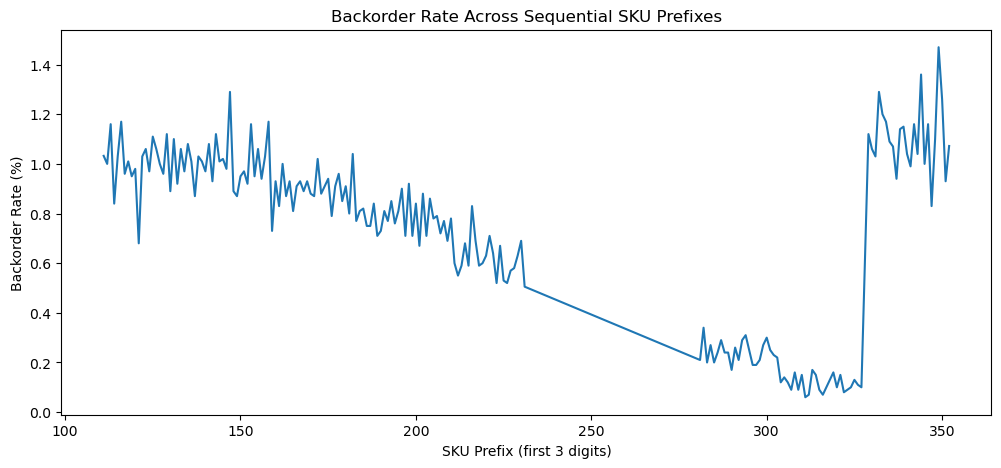

In [226]:
# Review backorder rate across SKU prefixes in numerical order

prefix_summary_ordered = (
    prefix_summary_filtered
    .assign(
        sku_prefix_numeric=lambda x:
            x["sku_prefix_3"].astype(int)
    )
    .sort_values("sku_prefix_numeric")
)

plt.figure(figsize=(12, 5))

plt.plot(
    prefix_summary_ordered["sku_prefix_numeric"],
    prefix_summary_ordered["backorder_rate"]
)

plt.xlabel("SKU Prefix (first 3 digits)")
plt.ylabel("Backorder Rate (%)")
plt.title("Backorder Rate Across Sequential SKU Prefixes")

plt.show()

Backorder risk shows a statistically significant association with the numerical SKU sequence.

In [227]:
# Review the numerical ranges represented in the dataset

prefix_summary_ordered[
    ["sku_prefix_3", "observations", "backorder_rate"]
].to_string(index=False)

'sku_prefix_3  observations  backorder_rate\n         111          8427          1.0324\n         112         10000          1.0000\n         113         10000          1.1600\n         114         10000          0.8400\n         115         10000          1.0300\n         116         10000          1.1700\n         117         10000          0.9600\n         118         10000          1.0100\n         119         10000          0.9500\n         120         10000          0.9800\n         121         10000          0.6800\n         122         10000          1.0300\n         123         10000          1.0600\n         124         10000          0.9700\n         125         10000          1.1100\n         126         10000          1.0600\n         127         10000          1.0000\n         128         10000          0.9600\n         129         10000          1.1200\n         130         10000          0.8900\n         131         10000          1.1000\n         132         10000     

In [228]:
# Measure association between numerical SKU prefix and backorder rate

from scipy.stats import spearmanr

spearman_corr, spearman_p = spearmanr(
    prefix_summary_ordered["sku_prefix_numeric"],
    prefix_summary_ordered["backorder_rate"]
)

print("Spearman correlation:", round(spearman_corr, 4))
print("p-value:", spearman_p)

Spearman correlation: -0.3875
p-value: 2.3850556222915722e-08


Backorder rates vary systematically across sequential SKU ranges, suggesting that the SKU identifier may contain latent structural information related to backorder risk.

In [229]:
# Compare SKU numerical ranges between the original training and testing datasets

for name, data in [
    ("Training", sku_train),
    ("Testing", sku_test)
]:
    sku_numeric = pd.to_numeric(
        data["sku"].astype(str).str.replace(".0", "", regex=False),
        errors="coerce"
    )

    print(f"\n{name}")
    print("Min SKU:", sku_numeric.min())
    print("Max SKU:", sku_numeric.max())
    print("Median SKU:", sku_numeric.median())
    print("Mean SKU:", round(sku_numeric.mean(), 2))


Training
Min SKU: 1026827.0
Max SKU: 3284919.0
Median SKU: 1955448.5
Mean SKU: 2094459.9

Testing
Min SKU: 3284920.0
Max SKU: 3526994.0
Median SKU: 3405957.0
Mean SKU: 3405957.0


In [230]:
# Compare SKU prefix distributions between training and testing datasets

for name, data in [
    ("Training", sku_train),
    ("Testing", sku_test)
]:
    prefix = (
        data["sku"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str[:3]
    )

    print(f"\n{name}")
    print(prefix.value_counts().sort_index().head())
    print("...")
    print(prefix.value_counts().sort_index().tail())


Training
sku
(16     1
102     1
104    15
105    15
106    23
Name: count, dtype: int64
...
sku
324    10000
325    10000
326    10000
327    10000
328     4920
Name: count, dtype: int64

Testing
sku
(24        1
328     5080
329    10000
330    10000
331    10000
Name: count, dtype: int64
...
sku
348    10000
349    10000
350    10000
351    10000
352     6995
Name: count, dtype: int64


Backorder rates vary across sequential SKU ranges. This pattern is investigated further to determine whether it reflects meaningful product structure or the way the original datasets were partitioned.

Although SKU prefixes showed differences in backorder rates, there is not enough evidence to interpret them as actual product families. Therefore, SKU was not introduced as a predictive feature, avoiding the risk of learning dataset-order patterns rather than meaningful supply-chain relationships.

Overall, this analysis supports the decision to evaluate the final model using the combined dataset with a new stratified train/test split, which produced much more consistent validation and test performance.

Based on this finding, the combined-dataset experiment below evaluates whether redistributing observations through a new stratified split produces more stable generalization performance.

## Dashboard dataset preparation

In [262]:
# Check whether the final untouched test set preserves original row indices

print("X_test_combined index:")
print(X_test_combined.index[:10])

print("\ny_test_combined index:")
print(y_test_combined.index[:10])

print("\nSame indices:")
print(X_test_combined.index.equals(y_test_combined.index))

print("\nIndex unique:")
print(X_test_combined.index.is_unique)

X_test_combined index:
Index([1032427,  429196, 1716436,  800741,  828649,  225663,  582987,  434211,
       1275538,  945264],
      dtype='int64')

y_test_combined index:
Index([1032427,  429196, 1716436,  800741,  828649,  225663,  582987,  434211,
       1275538,  945264],
      dtype='int64')

Same indices:
True

Index unique:
True


In [263]:
# Inspect the combined dataset structure before creating the dashboard dataset

print("X_combined shape:", X_combined.shape)
print("X_test_combined shape:", X_test_combined.shape)

print("\nCombined index sample:")
print(X_combined.index[:10])

print("\nTest index sample:")
print(X_test_combined.index[:10])

print("\nTest index range:")
print(X_test_combined.index.min(), X_test_combined.index.max())

X_combined shape: (1929935, 21)
X_test_combined shape: (385987, 21)

Combined index sample:
RangeIndex(start=0, stop=10, step=1)

Test index sample:
Index([1032427,  429196, 1716436,  800741,  828649,  225663,  582987,  434211,
       1275538,  945264],
      dtype='int64')

Test index range:
8 1929931


In [264]:
# Reconstruct the original SKU sequence used in X_combined

sku_combined = pd.concat(
    [
        sku_train["sku"],
        sku_test["sku"]
    ],
    axis=0,
    ignore_index=True
)

print("SKU combined shape:", sku_combined.shape)
print("X combined shape:", X_combined.shape)

print("\nSame number of observations:")
print(len(sku_combined) == len(X_combined))

SKU combined shape: (1929937,)
X combined shape: (1929935, 21)

Same number of observations:
False


In [265]:
# Recover the SKU corresponding to each observation
# in the final untouched test set

sku_test_final = sku_combined.loc[
    X_test_combined.index
].copy()

print("Final test SKU shape:", sku_test_final.shape)
print("Expected test shape:", len(X_test_combined))

print("\nExample SKUs:")
print(sku_test_final.head(10))

Final test SKU shape: (385987,)
Expected test shape: 385987

Example SKUs:
1032427    1390420
429196     1777175
1716436    3306108
800741     2148701
828649     2176616
225663     1337224
582987     1930953
434211     1782192
1275538    2858592
945264     2293252
Name: sku, dtype: object


In [266]:
# Final alignment checks

print(
    "SKU and X_test same length:",
    len(sku_test_final) == len(X_test_combined)
)

print(
    "SKU and target same length:",
    len(sku_test_final) == len(y_test_combined)
)

print(
    "SKU indices match X_test:",
    sku_test_final.index.equals(X_test_combined.index)
)

print(
    "Target indices match X_test:",
    y_test_combined.index.equals(X_test_combined.index)
)

SKU and X_test same length: True
SKU and target same length: True
SKU indices match X_test: True
Target indices match X_test: True


In [267]:
# Identify raw rows with invalid or missing target values

invalid_sku_rows = sku_analysis[
    sku_analysis["backorder_binary"].isna()
]

invalid_sku_rows

,sku,went_on_backorder,sku_family_3,backorder_binary,sku_prefix_3
1687860,(1687860 rows),NaN,(16,NaN,(16
1929936,(242075 rows),NaN,(24,NaN,(24


In [268]:
print("Invalid rows:", len(invalid_sku_rows))
print("Indices:", invalid_sku_rows.index.tolist())

Invalid rows: 2
Indices: [1687860, 1929936]


In [269]:
# Keep only SKU rows with a valid backorder target

sku_analysis_clean = (
    sku_analysis[
        sku_analysis["backorder_binary"].notna()
    ]
    .reset_index(drop=True)
)

print("Clean SKU observations:", len(sku_analysis_clean))
print("X combined observations:", len(X_combined))

print(
    "Same number of observations:",
    len(sku_analysis_clean) == len(X_combined)
)

Clean SKU observations: 1929935
X combined observations: 1929935
Same number of observations: True


In [270]:
# Recover correctly aligned SKUs for the final untouched test set

sku_combined_clean = sku_analysis_clean["sku"]

sku_test_final = (
    sku_combined_clean
    .loc[X_test_combined.index]
    .copy()
)

print("Final test SKU shape:", sku_test_final.shape)
print("Expected test shape:", X_test_combined.shape[0])

print(
    "SKU indices match X_test:",
    sku_test_final.index.equals(X_test_combined.index)
)

Final test SKU shape: (385987,)
Expected test shape: 385987
SKU indices match X_test: True


In [271]:
# Final integrity checks before building the dashboard dataset

print(
    "Combined rows aligned:",
    len(sku_combined_clean) == len(X_combined)
)

print(
    "Test SKU rows aligned:",
    len(sku_test_final) == len(X_test_combined)
)

print(
    "Test predictor/target indices aligned:",
    X_test_combined.index.equals(y_test_combined.index)
)

print(
    "Test SKU/predictor indices aligned:",
    sku_test_final.index.equals(X_test_combined.index)
)

Combined rows aligned: True
Test SKU rows aligned: True
Test predictor/target indices aligned: True
Test SKU/predictor indices aligned: True


### Proceed to create the dataset to use for a dashboard

In [272]:
# Create dashboard dataset from the final untouched test set

dashboard_df = X_test_combined.copy()

dashboard_df.insert(
    0,
    "sku",
    sku_test_final
)

dashboard_df["actual_backorder"] = y_test_combined

dashboard_df["backorder_probability"] = y_test_combined_prob

dashboard_df["predicted_backorder"] = y_test_combined_pred

print("Dashboard dataset shape:", dashboard_df.shape)

dashboard_df.head()

Dashboard dataset shape: (385987, 25)


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,actual_backorder,backorder_probability,predicted_backorder
1032427,1390420,2.0000,8.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0,0.0000,0.9900,0.9600,0.0000,0,0,0,1,0,0,0.0000,0
429196,1777175,44.0000,8.0000,0.0000,0.0000,0.0000,0.0000,5.0000,12.0000,25.0000,40.0000,0.0000,0,0.0000,0.9800,0.9200,0.0000,0,0,0,1,0,0,0.0000,0
1716436,3306109,7.0000,52.0000,0.0000,0.0000,0.0000,0.0000,2.0000,5.0000,14.0000,27.0000,5.0000,0,0.0000,0.7000,0.6300,0.0000,1,0,1,1,0,0,0.0000,0
800741,2148701,7.0000,8.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0,0.0000,0.7900,0.6700,0.0000,0,0,0,1,0,0,0.0000,0
828649,2176616,233.0000,52.0000,0.0000,0.0000,0.0000,0.0000,1.0000,7.0000,12.0000,16.0000,10.0000,0,0.0000,0.0000,0.0000,0.0000,1,0,0,1,0,0,0.0000,0


In [273]:
# Classify each prediction outcome

conditions = [
    (
        (dashboard_df["actual_backorder"] == 1) &
        (dashboard_df["predicted_backorder"] == 1)
    ),
    (
        (dashboard_df["actual_backorder"] == 0) &
        (dashboard_df["predicted_backorder"] == 1)
    ),
    (
        (dashboard_df["actual_backorder"] == 1) &
        (dashboard_df["predicted_backorder"] == 0)
    ),
    (
        (dashboard_df["actual_backorder"] == 0) &
        (dashboard_df["predicted_backorder"] == 0)
    )
]

choices = [
    "True Positive",
    "False Positive",
    "False Negative",
    "True Negative"
]

dashboard_df["prediction_outcome"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

In [274]:
dashboard_df["prediction_outcome"].value_counts()

prediction_outcome
True Negative     380707
False Positive      2484
False Negative      1459
True Positive       1337
Name: count, dtype: int64

In [275]:
# Flag whether the prediction was correct

dashboard_df["correct_prediction"] = (
    dashboard_df["actual_backorder"]
    ==
    dashboard_df["predicted_backorder"]
).astype(int)

In [276]:
# Add SKU prefix for descriptive dashboard analysis

dashboard_df["sku_prefix_3"] = (
    dashboard_df["sku"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str[:3]
)

In [277]:
# Review model probability distribution

dashboard_df["backorder_probability"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count   385,987.0000
mean          0.0191
std           0.0788
min           0.0000
50%           0.0000
75%           0.0000
90%           0.0300
95%           0.0900
99%           0.3996
max           1.0000
Name: backorder_probability, dtype: float64

In [278]:
# Review how many observations fall above selected probability thresholds

for threshold in [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80
]:

    count = (
        dashboard_df["backorder_probability"]
        >= threshold
    ).sum()

    percentage = (
        count / len(dashboard_df) * 100
    )

    print(
        f">= {threshold:.2f}: "
        f"{count:,} SKUs "
        f"({percentage:.2f}%)"
    )

>= 0.10: 19,060 SKUs (4.94%)
>= 0.20: 10,883 SKUs (2.82%)
>= 0.30: 7,395 SKUs (1.92%)
>= 0.40: 3,821 SKUs (0.99%)
>= 0.50: 2,736 SKUs (0.71%)
>= 0.60: 1,808 SKUs (0.47%)
>= 0.70: 1,246 SKUs (0.32%)
>= 0.80: 773 SKUs (0.20%)


In [279]:
# Create operational alert status using the final threshold

dashboard_df["alert_status"] = np.where(
    dashboard_df["backorder_probability"] >= 0.40,
    "Review",
    "No Alert"
)

In [280]:
# Review final dashboard structure

print("Rows:", dashboard_df.shape[0])
print("Columns:", dashboard_df.shape[1])

print("\nMissing values:")
print(
    dashboard_df.isna().sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nPrediction outcomes:")
print(
    dashboard_df["prediction_outcome"]
    .value_counts()
)

Rows: 385987
Columns: 29

Missing values:
sku                      0
perf_12_month_avg        0
sku_prefix_3             0
correct_prediction       0
prediction_outcome       0
predicted_backorder      0
backorder_probability    0
actual_backorder         0
rev_stop                 0
stop_auto_buy            0
dtype: int64

Prediction outcomes:
prediction_outcome
True Negative     380707
False Positive      2484
False Negative      1459
True Positive       1337
Name: count, dtype: int64


In [281]:
# Create model risk levels based on predicted backorder probability

dashboard_df["risk_level"] = pd.cut(
    dashboard_df["backorder_probability"],
    bins=[
        -np.inf,
        0.10,
        0.20,
        0.40,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "Elevated",
        "High"
    ],
    right=False
)

dashboard_df["risk_level"].value_counts()

risk_level
Low         366927
Moderate      8177
Elevated      7062
High          3821
Name: count, dtype: int64

In [282]:
# Confirm that High Risk corresponds to the operational alert threshold

print(
    "High risk SKUs:",
    (dashboard_df["risk_level"] == "High").sum()
)

print(
    "Review alerts:",
    (dashboard_df["alert_status"] == "Review").sum()
)

High risk SKUs: 3821
Review alerts: 3821


In [283]:
# Add readable classification labels for dashboard use

dashboard_df["actual_backorder_label"] = (
    dashboard_df["actual_backorder"]
    .map({
        0: "No Backorder",
        1: "Backorder"
    })
)

dashboard_df["predicted_backorder_label"] = (
    dashboard_df["predicted_backorder"]
    .map({
        0: "No Backorder",
        1: "Backorder"
    })
)

In [284]:
# Flag missed actual backorders for dashboard analysis

dashboard_df["missed_backorder"] = (
    dashboard_df["prediction_outcome"]
    == "False Negative"
).astype(int)

In [285]:
# Flag correctly detected backorders

dashboard_df["detected_backorder"] = (
    dashboard_df["prediction_outcome"]
    == "True Positive"
).astype(int)

In [286]:
# Create planner-oriented action priority

dashboard_df["planner_priority"] = np.select(
    [
        dashboard_df["backorder_probability"] >= 0.40,
        dashboard_df["backorder_probability"] >= 0.20,
        dashboard_df["backorder_probability"] >= 0.10
    ],
    [
        "Priority Review",
        "Monitor",
        "Watch"
    ],
    default="Routine"
)

In [287]:
# Organize dashboard columns for easier analysis

dashboard_columns = [
    # Identification
    "sku",
    "sku_prefix_3",

    # Model output
    "backorder_probability",
    "risk_level",
    "planner_priority",
    "alert_status",

    # Actual vs predicted
    "actual_backorder",
    "actual_backorder_label",
    "predicted_backorder",
    "predicted_backorder_label",
    "prediction_outcome",
    "correct_prediction",
    "detected_backorder",
    "missed_backorder",

    # Supply chain predictors
    "national_inv",
    "lead_time",
    "in_transit_qty",

    "forecast_3_month",
    "forecast_6_month",
    "forecast_9_month",

    "sales_1_month",
    "sales_3_month",
    "sales_6_month",
    "sales_9_month",

    "min_bank",
    "pieces_past_due",

    "perf_6_month_avg",
    "perf_12_month_avg",

    "local_bo_qty",

    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop"
]

dashboard_df = dashboard_df[
    dashboard_columns
].copy()

In [288]:
# Final validation of the dashboard dataset

print("Dashboard shape:", dashboard_df.shape)

print("\nMissing values:")
print(dashboard_df.isna().sum().sum())

print("\nDuplicated SKUs:")
print(dashboard_df["sku"].duplicated().sum())

print("\nRisk levels:")
print(dashboard_df["risk_level"].value_counts())

print("\nPlanner priorities:")
print(dashboard_df["planner_priority"].value_counts())

print("\nPrediction outcomes:")
print(dashboard_df["prediction_outcome"].value_counts())

Dashboard shape: (385987, 35)

Missing values:
0

Duplicated SKUs:
0

Risk levels:
risk_level
Low         366927
Moderate      8177
Elevated      7062
High          3821
Name: count, dtype: int64

Planner priorities:
planner_priority
Routine            366927
Watch                8177
Monitor              7062
Priority Review      3821
Name: count, dtype: int64

Prediction outcomes:
prediction_outcome
True Negative     380707
False Positive      2484
False Negative      1459
True Positive       1337
Name: count, dtype: int64


In [289]:
# Final consistency check between probability, threshold and prediction

threshold_check = (
    (
        dashboard_df["backorder_probability"] >= 0.40
    ).astype(int)
    == dashboard_df["predicted_backorder"]
)

print(
    "Predictions consistent with threshold:",
    threshold_check.all()
)

print(
    "Inconsistent rows:",
    (~threshold_check).sum()
)

Predictions consistent with threshold: True
Inconsistent rows: 0


In [290]:
# Export final dashboard-ready dataset

dashboard_output_path = (
    "../data/processed/backorder_dashboard.csv"
)

dashboard_df.to_csv(
    dashboard_output_path,
    index=False
)

print(
    "Dashboard dataset saved to:",
    dashboard_output_path
)

Dashboard dataset saved to: ../data/processed/backorder_dashboard.csv


In [291]:
# Confirm exported dashboard dataset

import os

print(
    "File exists:",
    os.path.exists(dashboard_output_path)
)

print(
    "File size (MB):",
    round(
        os.path.getsize(dashboard_output_path)
        / (1024 ** 2),
        2
    )
)

File exists: True
File size (MB): 61.12


In [3]:
# Export final feature importance for Tableau

feature_importance_output_path = (
    "../data/processed/feature_importance.csv"
)

feature_importance_final.to_csv(
    feature_importance_output_path,
    index=False
)

print("Feature importance exported to:")
print(feature_importance_output_path)

Feature importance exported to:
../data/processed/feature_importance.csv
